## Libraries

In [41]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Plot - after 5ns

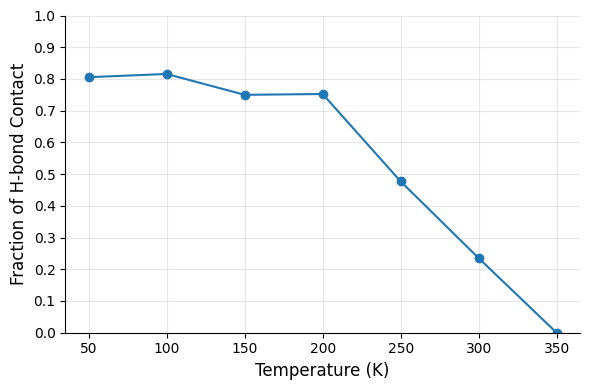

In [46]:
contacts_count_dir = Path('./contacts_dat')
start_frame = 3234  #6468305 steps = 10ns / 2 - drop early equilibration
max_pairs = 36         
temps     = []
fractions = []

for f in sorted(contacts_count_dir.glob('*_count.dat')):
    df = pd.read_csv(f, sep='\t')
    # 1) drop early frames
    df2 = df[df['Frame'] >= start_frame]
    if df2.empty:
        print(f"⚠️ {f.name} has no data after frame {start_frame}, skipping")
        continue
    
    # 2) compute average fraction of possible contacts
    #    this gives a number between 0 and 1
    frac = df2['NumContacts'].mean() / max_pairs

    # 3) parse temperature from filename
    m = re.search(r'(\d+)K', f.stem)
    if not m:
        continue
    temp = int(m.group(1))
    
    temps.append(temp)
    fractions.append(frac)

# assemble & sort
df_frac = pd.DataFrame({
    'Temperature (K)': temps,
    'Contact Fraction': fractions
}).sort_values('Temperature (K)')

# plot
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(df_frac['Temperature (K)'],
        df_frac['Contact Fraction'],
        marker='o', linestyle='-')

ax.set_xlabel('Temperature (K)', fontsize=12)
ax.set_ylabel('Fraction of H-bond Contact', fontsize=12)
ax.set_ylim(0, 1)                         
ax.set_yticks(np.linspace(0, 1, 11))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
